# Chapter 10 - Bet Sizing

## Preparation

In [79]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment

from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC

from utils.data_paths import IVE_TICKS
from utils.sampling_bars import dollar_bar
from utils.ef3m import M2N, rawMoment


%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

# df = pd.read_parquet(IVE_TICKS)
# dollar_bars = dollar_bar(df)

## 1. Using the formulation in Section 10.3, plot the bet size (m) as a function of the maximum predicted probability ($\widetilde{p}$) when ||X|| = 2, 3, ..., 10.

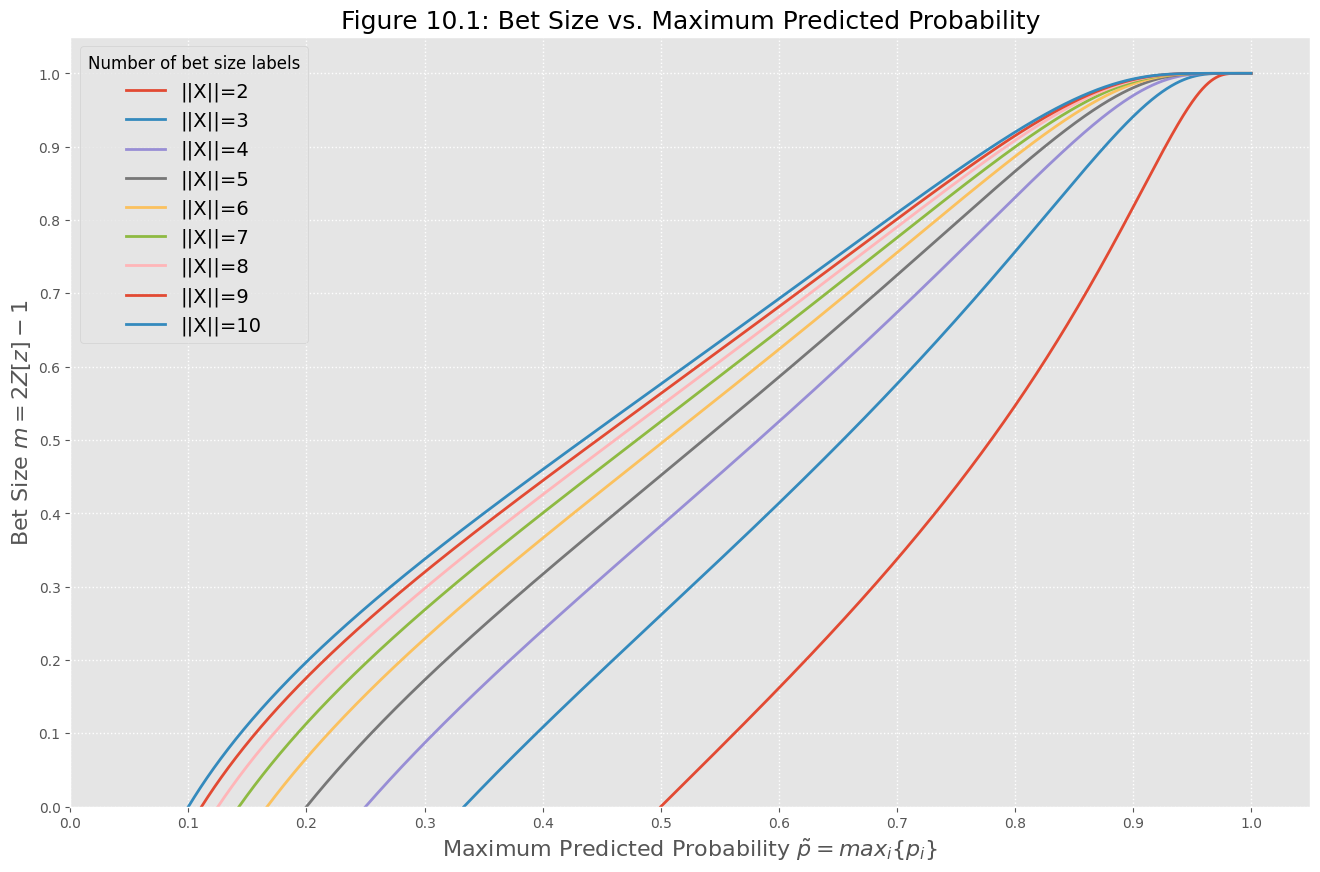

In [6]:
num_classes = range(2, 11)
num_points = 10000

fig, ax = plt.subplots(figsize=(16, 10))

for num_class in num_classes:
    min_prob, max_prob = 1 / num_class, 1
    P = np.linspace(min_prob, max_prob, num_points, endpoint=False)
    z = (P - min_prob) / (P*(1-P))**0.5
    m = 2 * norm.cdf(z) - 1
    ax.plot(P, m, label=f"||X||={num_class}", linewidth=2, alpha=1)

ax.set_ylabel("Bet Size $m=2Z[z]-1$", fontsize=16)
ax.set_xlabel(r"Maximum Predicted Probability $\tilde{p}=max_i${$p_i$}", fontsize=16)
ax.set_title("Figure 10.1: Bet Size vs. Maximum Predicted Probability", fontsize=18)
ax.set_xticks([0.1*i for i in range(11)])
ax.set_yticks([0.1*i for i in range(11)])
ax.legend(loc="upper left", fontsize=14, title="Number of bet size labels", title_fontsize=12)
ax.set_ylim((0,1.05))
ax.set_xlim((0, 1.05))
ax.grid(linewidth=1, linestyle=':')

## 2. Draw 10,000 random numbers from a uniform distribution with bounds U[.5,  1.].

In [23]:
np.random.seed(1016)
num_points = 10000
uniform_rand_nums = np.random.uniform(.5, 1., num_points)

### a. Compute the bet sizes m for ||X|| = 2.

In [24]:
z_uniform = (uniform_rand_nums - 0.5) / (uniform_rand_nums*(1-uniform_rand_nums))**0.5
m_uniform = 2 * norm.cdf(z_uniform) - 1

m_uniform

array([0.87635459, 0.682803  , 0.79161363, ..., 0.99994493, 0.99693435,
       0.70957452], shape=(10000,))

### b. Assign 10,000 consecutive calendar days to the bet sizes.

In [30]:
days = np.array([datetime.today() + pd.Timedelta(days=i) for i in range(num_points)])

### c. Draw 10,000 random numbers from a uniform distribution with bounds U[1, 25].

In [35]:
shift_dt = np.array([timedelta(days=d) for d in np.random.uniform(1, 25, num_points)])

### d. Form a pandas series indexed by the dates in 2.b, and with values equal  to the index shifted forward the number of days in 2.c. This is a t1 object similar to the ones we used in Chapter 3.

In [36]:
dates_shifted = days + shift_dt
t1 = pd.Series(data=dates_shifted, index=days)

t1

2026-06-01 20:55:16.781026   2026-06-06 05:41:44.163745
2026-06-02 20:55:16.781299   2026-06-20 14:49:17.852948
2026-06-03 20:55:16.781310   2026-06-18 12:36:10.301354
2026-06-04 20:55:16.781315   2026-06-22 06:43:35.031590
2026-06-05 20:55:16.781319   2026-06-19 21:04:29.624247
                                        ...            
2053-10-12 20:55:16.806729   2053-10-27 22:04:17.597073
2053-10-13 20:55:16.806731   2053-10-27 17:12:40.537448
2053-10-14 20:55:16.806733   2053-10-20 10:20:41.557276
2053-10-15 20:55:16.806735   2053-11-06 23:50:50.643284
2053-10-16 20:55:16.806737   2053-10-29 12:10:25.684745
Length: 10000, dtype: datetime64[us]

In [39]:
bet_sizes = pd.Series(m_uniform, index=days)

bet_sizes.head()

2026-06-01 20:55:16.781026    0.876355
2026-06-02 20:55:16.781299    0.682803
2026-06-03 20:55:16.781310    0.791614
2026-06-04 20:55:16.781315    0.645494
2026-06-05 20:55:16.781319    0.674013
dtype: float64

In [57]:
num_long_bets = bet_sizes[bet_sizes >= 0].count()
num_short_bets = bet_sizes[bet_sizes < 0].count()
print(f"Maximum number of concurrent long bets: {num_long_bets}")
print(f"Maximum number of concurrent short bets: {num_short_bets}")

Maximum number of concurrent long bets: 10000
Maximum number of concurrent short bets: 0


### e. Compute the resulting average active bets, following Section 10.4.

In [43]:
def average_active_bets(t1, bet_sizes):
    avg_bets = pd.Series()
    active_bets = pd.Series()
    
    for start_date, end_date in t1.items():
        active_idx = t1[(t1.index<=start_date)&(t1>start_date)].index
        num_active = len(active_idx)
        active_bets[start_date] = num_active
        avg_bets[start_date] = bet_sizes[active_idx].mean()
    
    return avg_bets, active_bets

In [44]:
avg_bets, active_bets = average_active_bets(t1, bet_sizes)

In [51]:
df_summary = pd.DataFrame({"t1": t1, "bet_sizes": bet_sizes, "avg_bets": avg_bets, "active_bets": active_bets}, index=days)

print("The first 15 records:")
df_summary.head(15)

The first 15 records:


,t1,bet_sizes,avg_bets,active_bets
2026-06-01 20:55:16.781026,2026-06-06 05:41:44.163745,0.876355,0.876355,1
2026-06-02 20:55:16.781299,2026-06-20 14:49:17.852948,0.682803,0.779579,2
2026-06-03 20:55:16.781310,2026-06-18 12:36:10.301354,0.791614,0.783590,3
2026-06-04 20:55:16.781315,2026-06-22 06:43:35.031590,0.645494,0.749066,4
2026-06-05 20:55:16.781319,2026-06-19 21:04:29.624247,0.674013,0.734056,5
2026-06-06 20:55:16.781323,2026-06-11 15:07:02.959209,0.275479,0.613880,5
2026-06-07 20:55:16.781327,2026-06-22 14:22:40.685297,0.759301,0.638117,6
2026-06-08 20:55:16.781330,2026-06-18 20:22:04.729687,0.972861,0.685938,7
2026-06-09 20:55:16.781333,2026-06-21 10:27:04.616484,0.330160,0.641465,8
2026-06-10 20:55:16.781336,2026-06-20 04:41:12.856507,0.740541,0.652474,9


In [52]:
print("The last 15 records:")
df_summary.tail(15)

The last 15 records:


,t1,bet_sizes,avg_bets,active_bets
2053-10-02 20:55:16.806708,2053-10-20 08:54:29.247057,0.708639,0.459631,18
2053-10-03 20:55:16.806710,2053-10-05 11:32:32.336265,0.865832,0.494036,18
2053-10-04 20:55:16.806712,2053-10-26 03:47:14.237380,0.498445,0.488983,16
2053-10-05 20:55:16.806714,2053-10-11 16:54:13.113639,0.166349,0.437720,15
2053-10-06 20:55:16.806716,2053-10-26 10:11:55.744548,0.628835,0.449664,16
2053-10-07 20:55:16.806718,2053-10-21 23:13:07.824945,0.077962,0.392310,14
2053-10-08 20:55:16.806721,2053-10-29 16:19:53.032789,0.388759,0.364631,14
2053-10-09 20:55:16.806723,2053-10-11 03:01:46.287926,0.839234,0.415022,14
2053-10-10 20:55:16.806725,2053-11-01 19:02:58.708918,0.547352,0.420364,14
2053-10-11 20:55:16.806727,2053-10-19 13:09:31.281592,0.122314,0.384756,13


In [54]:
print("Summary statistics:")
df_summary[["bet_sizes", "avg_bets", "active_bets"]].describe()

Summary statistics:


,bet_sizes,avg_bets,active_bets
count,10000.000000,10000.000000,10000.000000
mean,0.479616,0.477515,13.466200
std,0.310628,0.086190,2.038792
min,0.000004,0.149288,1.000000
25%,0.211566,0.418850,12.000000
50%,0.441735,0.477026,13.000000
75%,0.742441,0.535506,15.000000
max,1.000000,0.876355,20.000000


## 3. Using the t1 object from exercise 2.d:

#### Although we are told to use the t1 object from exercise 2.d, but since the probability is drawn from U[0.5,1], there will not be short bets. So here we rerun exercise 2 with a new probability distribution of U[0,1].

In [60]:
new_probs = np.random.uniform(0, 1., num_points)
new_z = (new_probs - 0.5) / (new_probs*(1-new_probs))**0.5
new_m = 2 * norm.cdf(new_z) - 1

new_bet_sizes = pd.Series(new_m, index=days)

new_bet_sizes.head()
num_long_bets = new_bet_sizes[new_bet_sizes >= 0].count()
num_short_bets = new_bet_sizes[new_bet_sizes < 0].count()
print(f"Maximum number of concurrent long bets: {num_long_bets}")
print(f"Maximum number of concurrent short bets: {num_short_bets}")

Maximum number of concurrent long bets: 4967
Maximum number of concurrent short bets: 5033


In [62]:
new_avg_bets, new_active_bets = average_active_bets(t1, new_bet_sizes)

new_df_summary = pd.DataFrame({"t1": t1, "p": new_probs, "bet_sizes": new_bet_sizes, "avg_bets": new_avg_bets, "active_bets": new_active_bets}, index=days)

new_df_summary.head(15)

,t1,p,bet_sizes,avg_bets,active_bets
2026-06-01 20:55:16.781026,2026-06-06 05:41:44.163745,0.334698,-0.273888,-0.273888,1
2026-06-02 20:55:16.781299,2026-06-20 14:49:17.852948,0.658276,0.261403,-0.006242,2
2026-06-03 20:55:16.781310,2026-06-18 12:36:10.301354,0.095934,-0.829947,-0.280811,3
2026-06-04 20:55:16.781315,2026-06-22 06:43:35.031590,0.339073,-0.266099,-0.277133,4
2026-06-05 20:55:16.781319,2026-06-19 21:04:29.624247,0.622449,0.199414,-0.181823,5
2026-06-06 20:55:16.781323,2026-06-11 15:07:02.959209,0.036671,-0.986304,-0.324307,5
2026-06-07 20:55:16.781327,2026-06-22 14:22:40.685297,0.437855,-0.099684,-0.286869,6
2026-06-08 20:55:16.781330,2026-06-18 20:22:04.729687,0.251488,-0.433207,-0.307775,7
2026-06-09 20:55:16.781333,2026-06-21 10:27:04.616484,0.873607,0.739128,-0.176912,8
2026-06-10 20:55:16.781336,2026-06-20 04:41:12.856507,0.088299,-0.853229,-0.252058,9


### a Determine the maximum number of concurrent long bets, $\bar{c}_l$.

In [63]:
active_long = pd.Series()
active_short = pd.Series()

for idx in new_df_summary.index:
    # long bets are defined as having a prediction probability greater than or equal to 0.5
    df_long_active_idx = set(new_df_summary[(new_df_summary.index<=idx) & (new_df_summary.t1>idx) & (new_df_summary.p>=0.5)].index)
    active_long[idx] = len(df_long_active_idx)
    # short bets are defined as having a prediction probability less than 0.5
    df_short_active_idx = set(new_df_summary[(new_df_summary.index<=idx) & (new_df_summary.t1>idx) & (new_df_summary.p<0.5)].index)
    active_short[idx] = len(df_short_active_idx)

print(f"Maximum number of concurrent long bets: {active_long.max()}")

Maximum number of concurrent long bets: 15


### b. Determine the maximum number of concurrent short bets, $\bar{c}_s$.

In [64]:
print(f"Maximum number of concurrent short bets: {active_short.max()}")

Maximum number of concurrent short bets: 14


### c. Derive the bet size as $m_t = c_{t,l}\frac{1}{\bar{c_l}} - c_{t,s}\frac{1}{\bar{c_s}}$, where $c_{t,l}$ is the number of concurrent long bets at time t, and $c_{t,s}$ is the number of concurrent short bets at time t.

In [67]:
avg_active_long = active_long/active_long.max() if active_long.max() > 0 else active_long
avg_active_short = active_short/active_short.max() if active_short.max() > 0 else active_short

bet_sizes_2 = avg_active_long - avg_active_short

In [68]:
bet_sizes_2.head(15)

2026-06-01 20:55:16.781026   -0.071429
2026-06-02 20:55:16.781299   -0.004762
2026-06-03 20:55:16.781310   -0.076190
2026-06-04 20:55:16.781315   -0.147619
2026-06-05 20:55:16.781319   -0.080952
2026-06-06 20:55:16.781323   -0.080952
2026-06-07 20:55:16.781327   -0.152381
2026-06-08 20:55:16.781330   -0.223810
2026-06-09 20:55:16.781333   -0.157143
2026-06-10 20:55:16.781336   -0.228571
2026-06-11 20:55:16.781339   -0.228571
2026-06-12 20:55:16.781342   -0.300000
2026-06-13 20:55:16.781345   -0.233333
2026-06-14 20:55:16.781348   -0.304762
2026-06-15 20:55:16.781350   -0.238095
dtype: float64

In [86]:
new_df_summary["bet_size_budgeting"] = bet_sizes_2

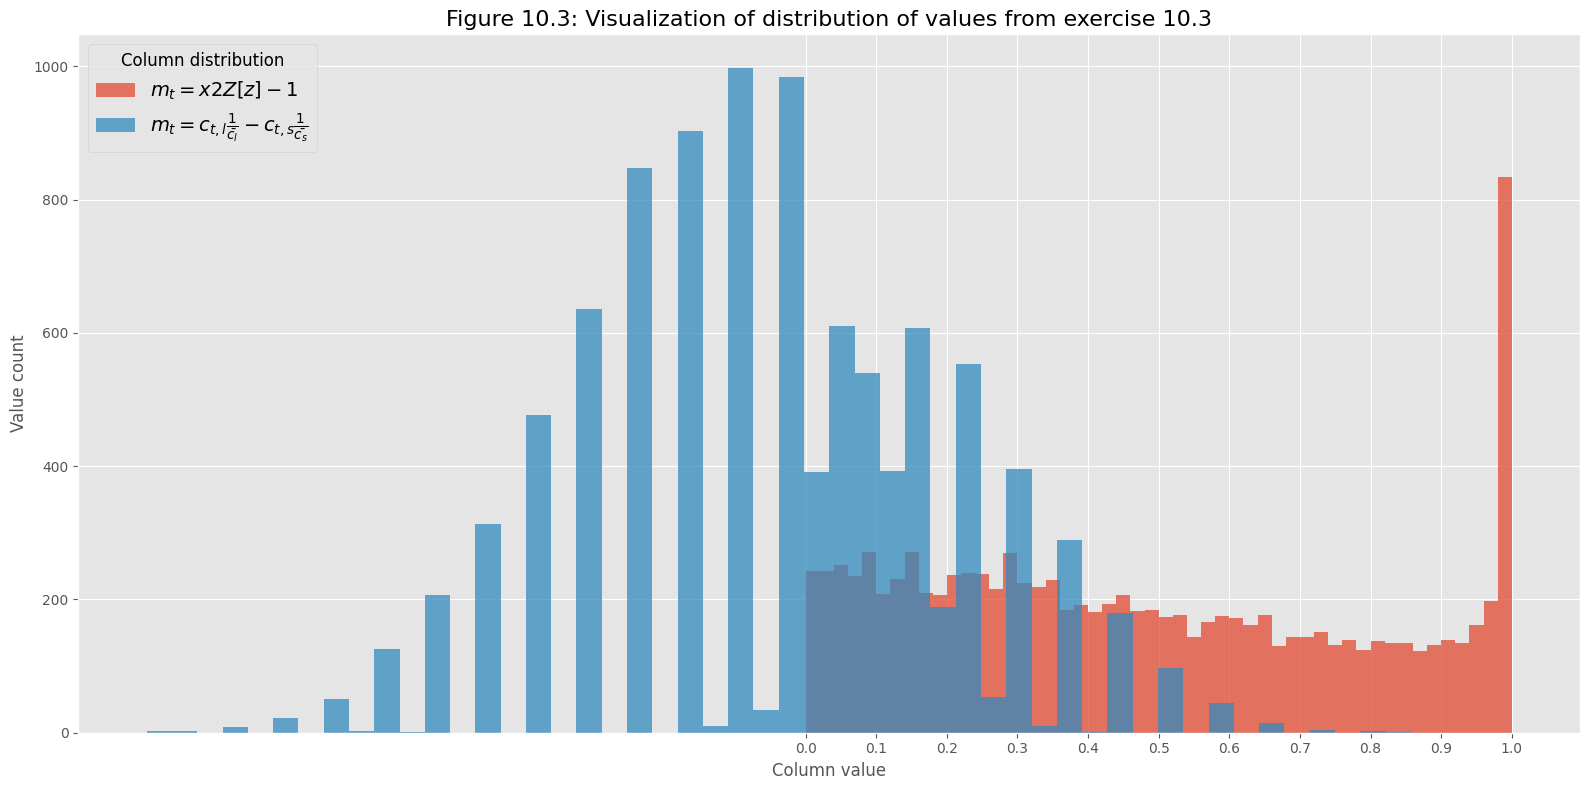

In [71]:
# plot the frequency of different bet sizes
fig, ax = plt.subplots(figsize=(16, 8))
n_bins = 50

ax.hist(df_summary["bet_sizes"], bins=n_bins, alpha=0.75, label=r"$m_t = x2Z[z]-1$")
ax.hist(bet_sizes_2, bins=n_bins, alpha=0.75, label=r"$m_t = c_{t,l}\frac{1}{\bar{c_l}} - c_{t,s}\frac{1}{\bar{c_s}}$")
ax.set_xticks([i/10 for i in range(11)])
ax.set_xlabel("Column value", fontsize=12)
ax.set_ylabel("Value count", fontsize=12)
ax.set_title("Figure 10.3: Visualization of distribution of values from exercise 10.3", fontsize=16)
ax.legend(loc="upper left", fontsize=14, title="Column distribution", title_fontsize=12)
fig.tight_layout()
plt.show()

## 4. Using the t1 object from exercise 2.d:

### a. Compute the series $c_t = c_{t,l} - c_{t,s}$, where $c_{t,l}$ is the number of concurrent long bets at time $t$, and $c_{t,s}$ is the number of concurrent short bets at time $t$.

In [73]:
c = active_long - active_short

c.head(15)

2026-06-01 20:55:16.781026   -1
2026-06-02 20:55:16.781299    0
2026-06-03 20:55:16.781310   -1
2026-06-04 20:55:16.781315   -2
2026-06-05 20:55:16.781319   -1
2026-06-06 20:55:16.781323   -1
2026-06-07 20:55:16.781327   -2
2026-06-08 20:55:16.781330   -3
2026-06-09 20:55:16.781333   -2
2026-06-10 20:55:16.781336   -3
2026-06-11 20:55:16.781339   -3
2026-06-12 20:55:16.781342   -4
2026-06-13 20:55:16.781345   -3
2026-06-14 20:55:16.781348   -4
2026-06-15 20:55:16.781350   -3
dtype: int64

In [88]:
new_df_summary["c"] = c

/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_86867/3831037124.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(c, bins=20, kde=True, kde_kws={"bw":0.6}, norm_hist=False, ax=ax)
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=0.6`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


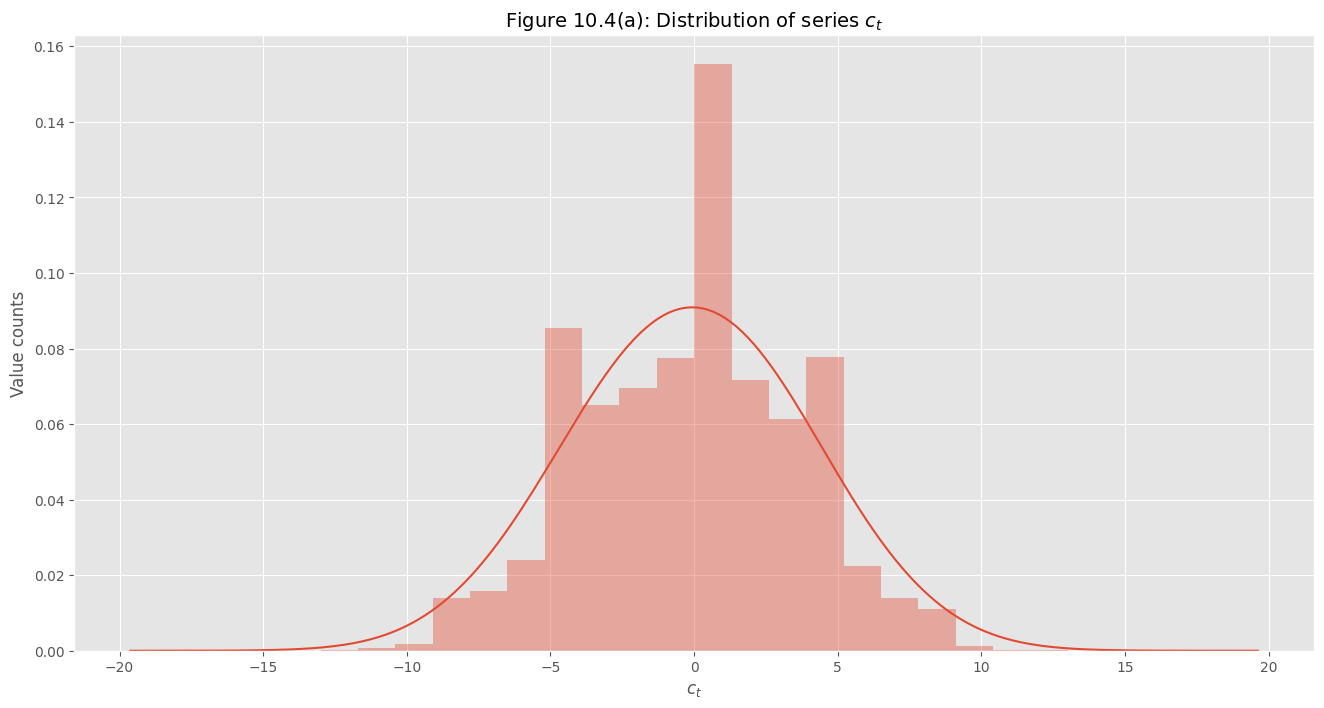

In [76]:
fig, ax = plt.subplots(figsize=(16, 8))
ax = sns.distplot(c, bins=20, kde=True, kde_kws={"bw":0.6}, norm_hist=False, ax=ax)
ax.set_xlabel('$c_t$', fontsize=12)
ax.set_ylabel("Value counts", fontsize=12)
ax.set_title("Figure 10.4(a): Distribution of series $c_t$", fontsize=14)
plt.show()

### b. Fit a mixture of two Gaussians on {$c_t$}. You may want to use the method described in López de Prado and Foreman (2014).

In [ ]:
print(f"Mean (first raw moment): {c.mean()}")
print("First 5 centered moments")
centered_moments_c = [moment(c.to_numpy(), moment=i) for i in range(1, 6)]
for i, mnt in enumerate(centered_moments_c):
    print(f"E[r^{i+1}] = {mnt}")

Mean (first raw moment): -0.1338
First 5 centered moments
E[r^1] = 0.0
E[r^2] = 13.51369756
E[r^3] = -0.8510064529440017
E[r^4] = 501.20265189055016
E[r^5] = -85.27713220530018


In [ ]:
# Calculate raw moments from centered moments
raw_moments = rawMoment(central_moments=centered_moments_c, dist_mean=c.mean())
for i, mnt in enumerate(raw_moments):
    print(f"E_Raw[r^{i+1}]={mnt}")

E_Raw[r^1]=-0.1338
E_Raw[r^2]=13.531600000000001
E_Raw[r^3]=-6.277800000000003
E_Raw[r^4]=503.11
E_Raw[r^5]=-421.05779999999936


/Users/lucaswychan/advances-in-financial-ml-exercises/utils/ef3m.py:201: RuntimeWarning: invalid value encountered in scalar power
  a = ( 6*sigma2**4 + (m4-p1*(3*sigma1**4+6*sigma1**2*mu1**2+mu1**4)) /\
/Users/lucaswychan/advances-in-financial-ml-exercises/utils/ef3m.py:201: RuntimeWarning: invalid value encountered in scalar power
  a = ( 6*sigma2**4 + (m4-p1*(3*sigma1**4+6*sigma1**2*mu1**2+mu1**4)) /\
/Users/lucaswychan/advances-in-financial-ml-exercises/utils/ef3m.py:201: RuntimeWarning: invalid value encountered in scalar power
  a = ( 6*sigma2**4 + (m4-p1*(3*sigma1**4+6*sigma1**2*mu1**2+mu1**4)) /\
/Users/lucaswychan/advances-in-financial-ml-exercises/utils/ef3m.py:201: RuntimeWarning: invalid value encountered in scalar power
  a = ( 6*sigma2**4 + (m4-p1*(3*sigma1**4+6*sigma1**2*mu1**2+mu1**4)) /\
/Users/lucaswychan/advances-in-financial-ml-exercises/utils/ef3m.py:201: RuntimeWarning: invalid value encountered in scalar power
  a = ( 6*sigma2**4 + (m4-p1*(3*sigma1**4+6*sigma1**2

=== Values chosen based on the mode of the distribution of results from EF3M (200 runs) ===
Most probable estimate for parameter 'mu1': -2.393
Most probable estimate for parameter 'mu2': 2.001


/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_86867/4168737383.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax_single = sns.distplot(df_10_4[col], bins=bins, kde=True, ax=ax_single)
/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_86867/4168737383.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750b

Most probable estimate for parameter 'sigma1': 2.963
Most probable estimate for parameter 'sigma2': 2.941
Most probable estimate for parameter 'p1': 0.486


/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_86867/4168737383.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax_single = sns.distplot(df_10_4[col], bins=bins, kde=True, ax=ax_single)
/var/folders/jz/5x8l_3b512v8q13q14lhl6nc0000gn/T/ipykernel_86867/4168737383.py:20: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750b

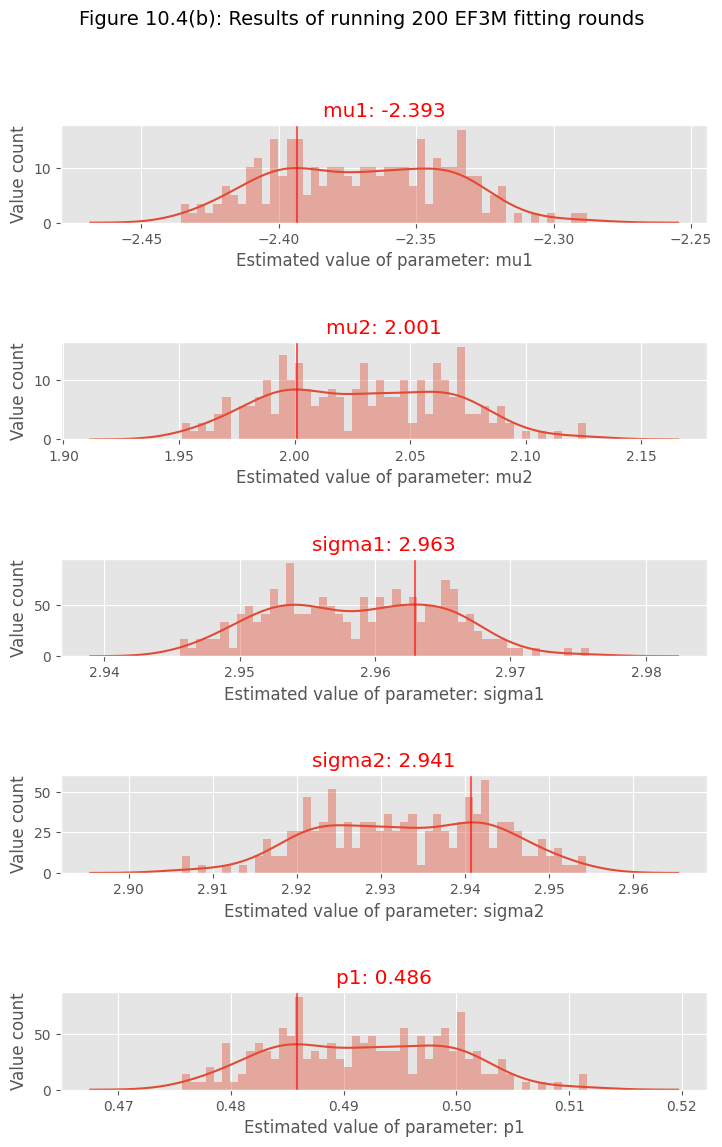

In [87]:
n_runs = 200
m2n = M2N(raw_moments)
df_10_4 = m2n.mpFit(raw_moments, epsilon=10**-5, factor=5, n_runs=n_runs, variant=2, maxIter=10_000_000)


# Visualize results and determine the most likely values from a KDE plot
# ======================================================
fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(8,12))
cols = ['mu1', 'mu2', 'sigma1', 'sigma2', 'p1']
bins = int(n_runs / 4)  # to minimize number of bins without results, choose at own discretion
fit_parameters = []

print(f"=== Values chosen based on the mode of the distribution of results from EF3M ({n_runs} runs) ===")

for col_i, ax_single in enumerate(ax.flatten()):
    col = cols[col_i]
    df = df_10_4.copy()
    df[col+'_bin'] = pd.cut(df[col], bins=bins)
    df = df.groupby([col+'_bin']).count()
    ax_single = sns.distplot(df_10_4[col], bins=bins, kde=True, ax=ax_single)
    dd = ax_single.get_lines()[0].get_data()
    most_probable_val = dd[0][np.argmax(dd[1])]
    fit_parameters.append(most_probable_val)
    ax_single.set_ylabel("Value count")
    ax_single.set_xlabel(f"Estimated value of parameter: {col}")
    ax_single.axvline(most_probable_val, color='red', alpha=0.6)
    ax_single.set_title(f"{col}: {round(most_probable_val,3)}", color='red')
    print(f"Most probable estimate for parameter '{col}':", round(dd[0][np.argmax(dd[1])], 3))
fig.suptitle(f"Figure 10.4(b): Results of running {n_runs} EF3M fitting rounds", fontsize=14)
fig.tight_layout(pad=3.5)
plt.show()

The CDF of a [mixture of $n$ distributions](https://en.wikipedia.org/wiki/Mixture_distribution), $F_{mixture}(x)$, can be represented as the weighted sum of the individual distributions:
$$ F_{mixture}(x) = \sum_{i=1}^{n}{w_i F_{i, norm}(x)}$$
Where $w_i$ are the weights corresponding to each of the individual cumulative distribution functions of a normal distribution, $F_{i,norm}(x)$.

Thus, for the mixture of $n=2$ distributions in this question, the CDF of the mixture, $F(x)$, is:
$$ F(x) = p_1 F_{norm}(x, \mu_1, \sigma_1) + (1-p_1) F_{norm}(x, \mu_2, \sigma_2) $$
Where $F_{norm}(x, \mu_i, \sigma_i)$ is the cumulative distribution evaluated at $x$ of a Normal distribution with parameters $\mu_i$ and $\sigma_i$, and $p_1$ is the probability of a given random sample being drawn from the first distribution.

### c. Derive the bet size as $$m_t = \begin{cases} \frac{F[c_t]-F[0]}{1-F[0]}, & \text{if } c_t\geq 0\\\ \frac{F[c_t]-F[0]}{F[0]}, & \text{if } c_t\le 0 \end{cases}$$ where $F[x]$ is the CDF of the fitted mixture of two Gaussians for a value of $x$.

,c,bet_size_budgeting,bet_size_mixture
count,10000.000000,10000.000000,10000.000000
mean,-0.133800,-0.041301,-0.011841
std,3.676282,0.253904,0.576374
min,-13.000000,-0.933333,-0.999837
25%,-3.000000,-0.233333,-0.557440
50%,0.000000,-0.033333,0.000000
75%,2.000000,0.114286,0.404816
max,13.000000,0.857143,0.999903


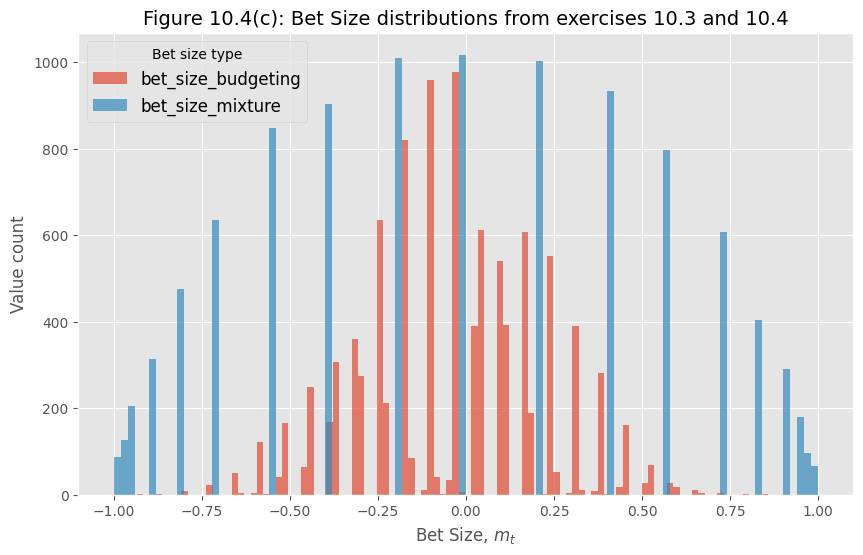

In [89]:
def cdf_mixture(x, parameters):
    # the CDF of a mixture of 2 normal distributions, evaluated at x
    # :param x: (float) x-value
    # :param parameters: (list) mixture parameters, [mu1, mu2, sigma1, sigma2, p1]
    # :return: (float) CDF of the mixture
    # ===================================
    mu1, mu2, sigma1, sigma2, p1 = parameters  # for clarity
    return p1*norm.cdf(x, mu1, sigma1) + (1-p1)*norm.cdf(x, mu2, sigma2)

def bet_size_mixture(c_t, parameters):
    # return m_t based on c_t
    F_0 = cdf_mixture(0, parameters)
    if c_t >= 0:
        return (cdf_mixture(c_t, parameters) - F_0) / (1 - F_0)
    else:
        return (cdf_mixture(c_t, parameters) - F_0) / F_0

new_df_summary["bet_size_mixture"] = new_df_summary["c"].apply(lambda c: bet_size_mixture(c, fit_parameters))

fig, ax = plt.subplots(figsize=(10,6))
for c in ['bet_size_budgeting', 'bet_size_mixture']:
    ax.hist(new_df_summary[c].to_numpy(), bins=100, label=c, alpha=0.7)
ax.legend(loc='upper left', fontsize=12, title="Bet size type", title_fontsize=10)
ax.set_xlabel("Bet Size, $m_t$", fontsize=12)
ax.set_ylabel("Value count", fontsize=12)
ax.set_title("Figure 10.4(c): Bet Size distributions from exercises 10.3 and 10.4", fontsize=14)
display(new_df_summary[['c', 'bet_size_budgeting', 'bet_size_mixture']].describe())

### d. Explain how this series $\{m_t\}$ differ from the bet size series computed in  exercise 3.

In exercise 3, we compute the bet size with the `budgeting` approach, and we compute the bet size with the `mixture of Gaussians` in exercise 4. We can see that the `bet_size_budgeting` tends to concentrate near 0, while `bet_size_mixture` tends to spread widely.

## 5. Repeat exercise 1, where you discretize m with a stepSize=.01,  stepSize=.05, and stepSize=.1.

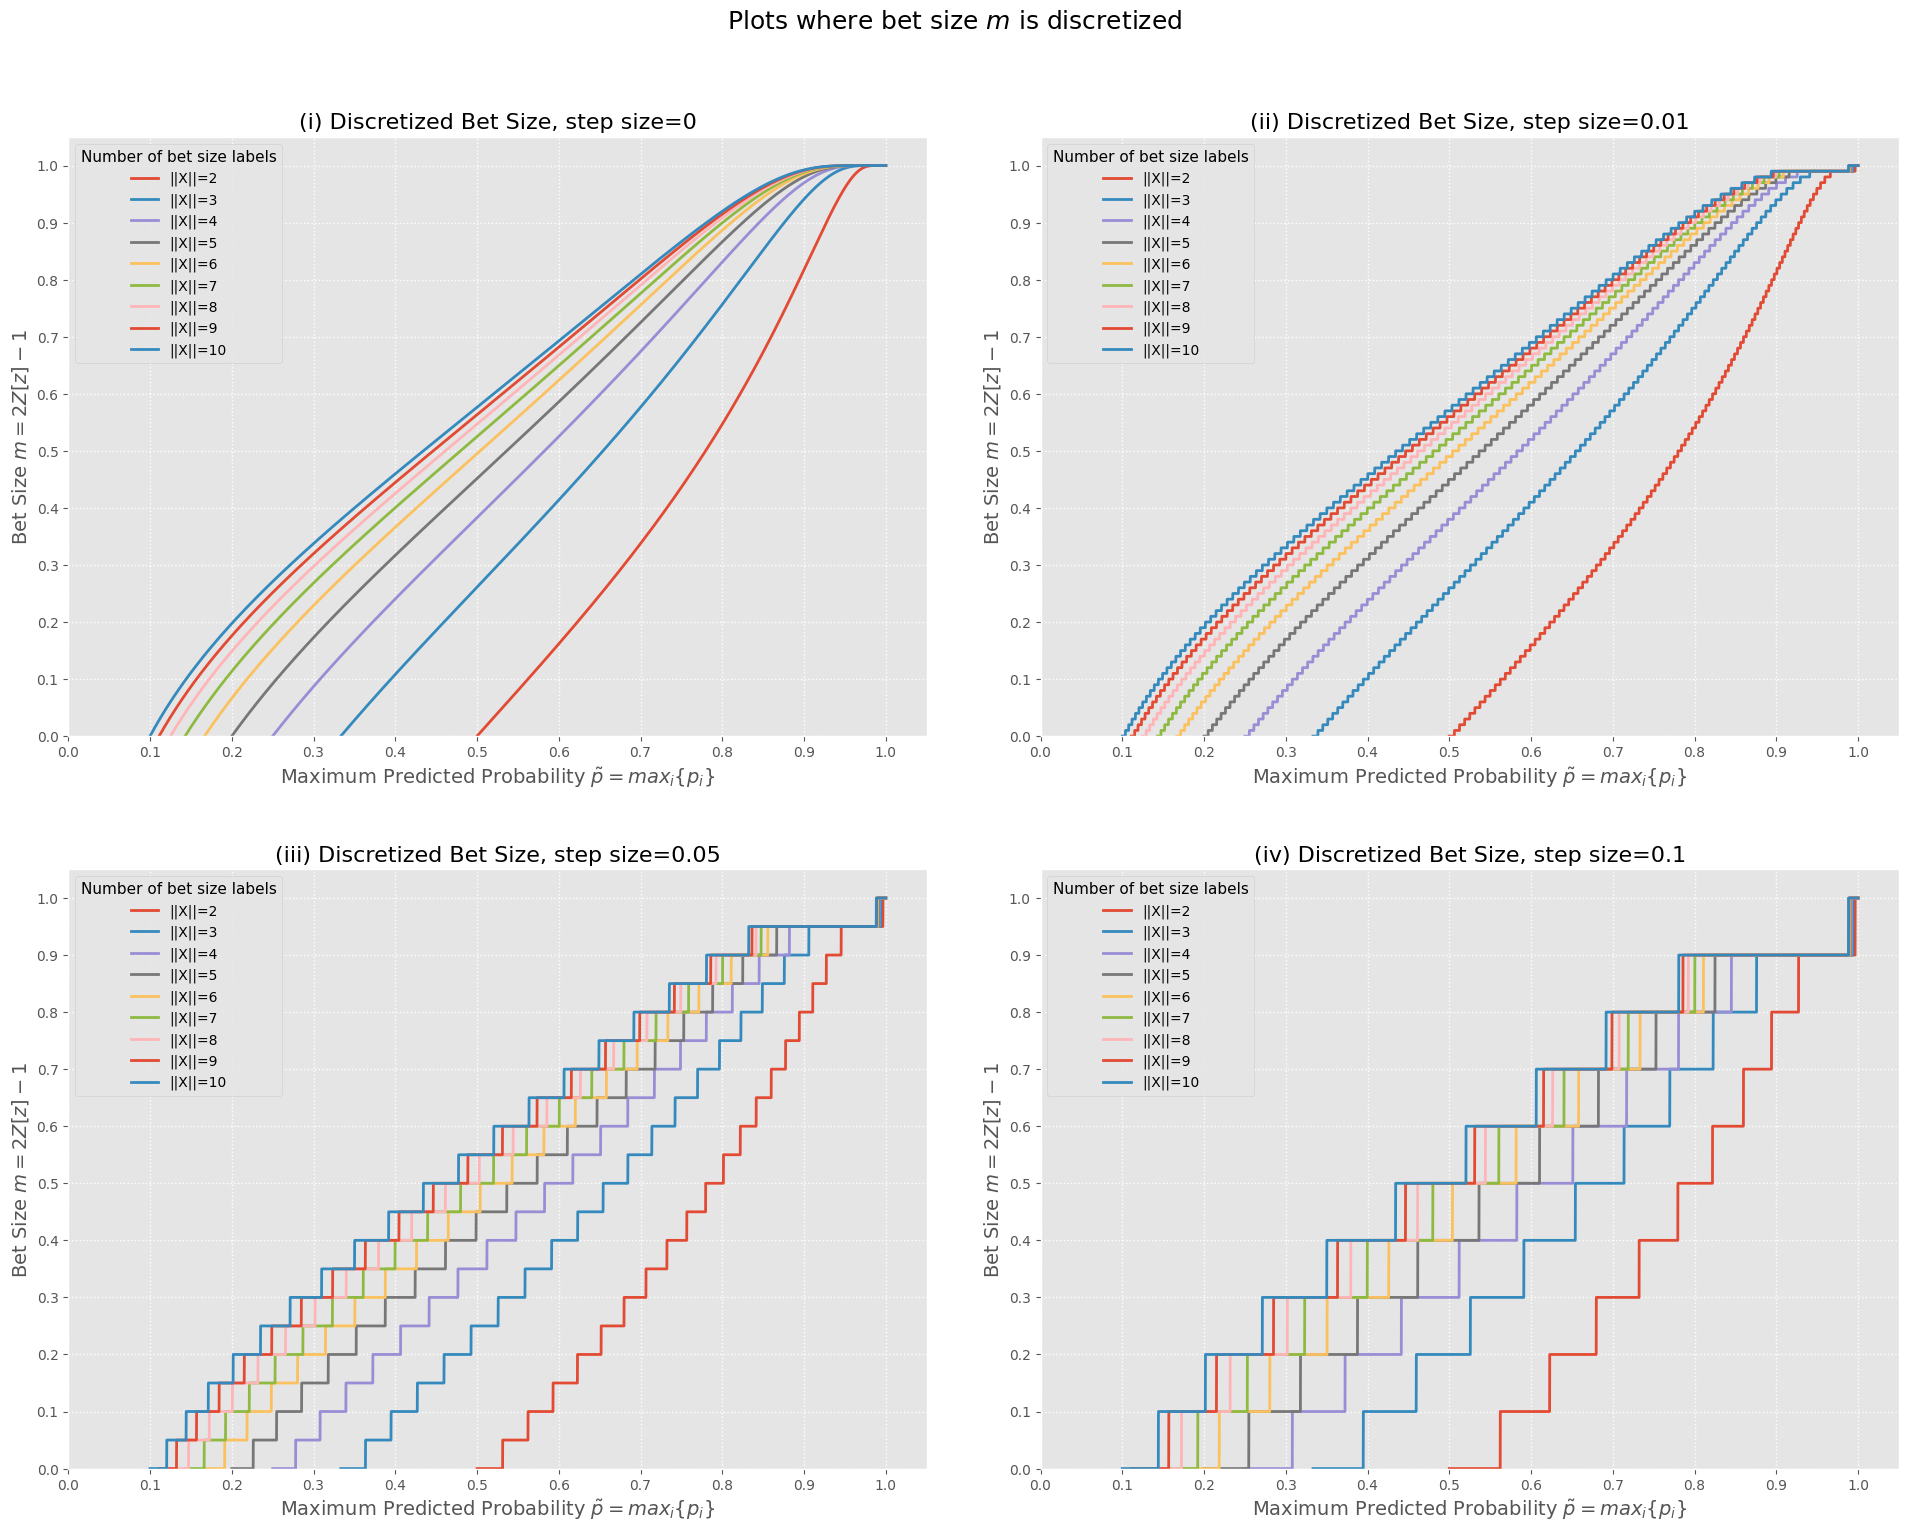

In [93]:
def discrete_signal(signal, step_size):
    discretized_signal = np.floor(signal/step_size) * step_size
    # cap the signal
    discretized_signal = np.clip(discretized_signal, -1, 1)
    return discretized_signal

num_classes = range(2, 11)
num_points = 10000
step_sizes = [0, 0.01, 0.05, 0.1]
sub_fig_indicators = ['i', 'ii', 'iii', 'iv']

fig, ax = plt.subplots(2, 2, figsize=(20, 16))
ax = fig.get_axes()

for i, ax_single in enumerate(ax):
    for num_class in num_classes:
        min_prob, max_prob = 1 / num_class, 1
        P = np.linspace(min_prob, max_prob, num_points, endpoint=False)
        z = (P - min_prob) / (P*(1-P))**0.5
        m = 2 * norm.cdf(z) - 1
        if step_sizes[i] > 0:
            m = discrete_signal(m, step_sizes[i])
        ax_single.plot(P, m, label=f"||X||={num_class}", linewidth=2, alpha=1)

    ax_single.set_ylabel("Bet Size $m=2Z[z]-1$", fontsize=14)
    ax_single.set_xlabel(r"Maximum Predicted Probability $\tilde{p}=max_i${$p_i$}", fontsize=14)
    ax_single.set_xticks([0.1*i for i in range(11)])
    ax_single.set_yticks([0.1*i for i in range(11)])
    ax_single.legend(loc="upper left", fontsize=10, title="Number of bet size labels", title_fontsize=11)
    ax_single.set_ylim((0,1.05))
    ax_single.set_xlim((0, 1.05))
    if not isinstance(step_sizes[i], type(None)):
        ax_single.set_title(f"({sub_fig_indicators[i]}) Discretized Bet Size, step size={step_sizes[i]}", fontsize=16)
    else:
        ax_single.set_title(f"({sub_fig_indicators[i]}) Continuous Bet Size", fontsize=16)
    ax_single.grid(linewidth=1, linestyle=':')

fig.suptitle("Plots where bet size $m$ is discretized", fontsize=18)
fig.tight_layout(pad=4)
plt.show()

### 6. Rewrite the equations in Section 10.6, so that the bet size is determined by a  power function rather than a sigmoid function.

We can substitute a power function to calculate bet size, $\tilde{m}$:

$$\tilde{m}[\omega, x] = sgn[x]|x|^\omega$$

$L[f_i, \omega, \tilde{m}]$, the inverse function of $\tilde{m}[\omega, x]$ with respect to the market price $p_t$, can be rewritten as:

$$L[f_i, \omega, \tilde{m}] = f_i - sgn[\tilde{m}]|\tilde{m}|^{1/\omega}$$

The inverse of $\tilde{m}[\omega, x]$ with respect to $\omega$ can be rewritten as:

$$\omega = \frac{log[\frac{\tilde{m}}{sgn(x)}]}{log[|x|]}$$

Where $x = f_i - p_t$ is still the divergence between the current market price, $p_t$, and the price forecast, $f_i$.

## 7. Modify Snippet 10.4 so that in implements the equations you derived in exercise 6.

In [98]:
def bet_size_power(w, x):
    # returns the bet size given the price divergence
    sgn = np.sign(x)
    return sgn * abs(x)**w

def bet_size_sigmoid(w, x):
    return x / np.sqrt(w + x**2)

def get_t_pos(w, f_i, p_t, max_pos):
    return int(bet_size_power(w, f_i-p_t)*max_pos)

def inv_price_power(f_i, w, m):
    sgn = np.sign(m)
    return f_i - sgn*abs(m)**(1/w)

def limit_price_power(t_pos, pos, f, w, max_pos):
    # returns the limit price given forecast price
    
    sgn = 1 if t_pos >= pos else -1
    l_p = 0
    for j in range(abs(pos+sgn), abs(t_pos+1)):
        l_p += inv_price_power(f, w, j/float(max_pos))
    l_p = l_p / (t_pos - pos)
    return l_p

def get_w(x, m):
    # inverse function of the bet size with respect to the 'w' coefficient
    return np.log(m/np.sign(x)) / np.log(abs(x))

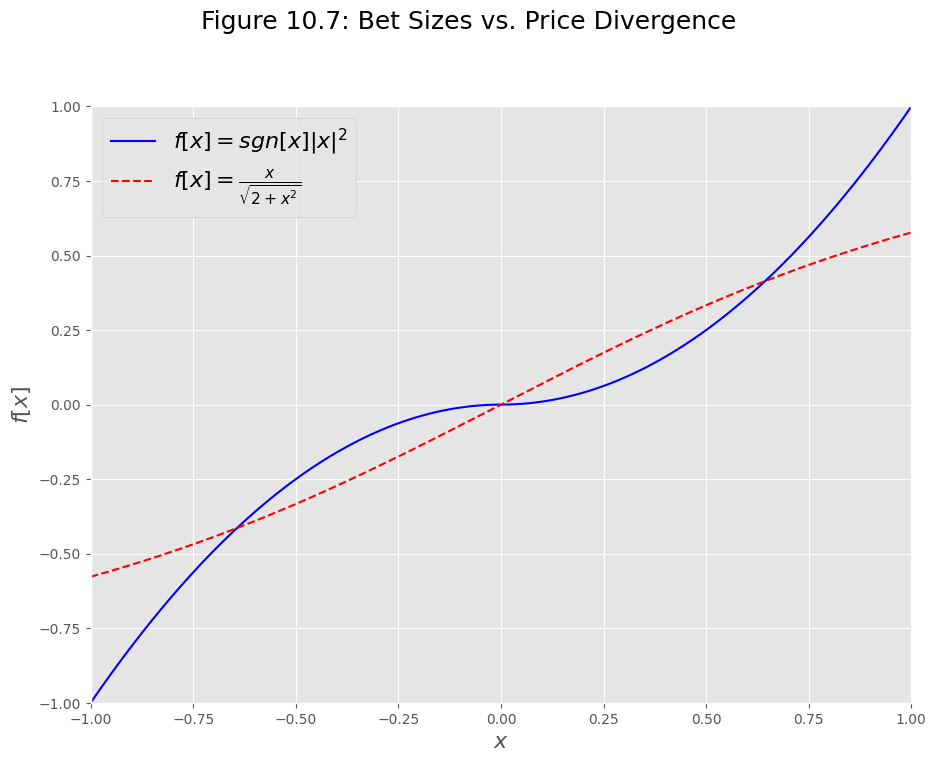

In [101]:
# setup data for replicating Figure 10.3
n_points = 1000
X = np.linspace(-1.0, 1.0, n_points)

w = 2
bet_sizes_power_list = np.array([bet_size_power(w, xi) for xi in X])
bet_sizes_sigmoid_list = np.array([bet_size_sigmoid(w, xi) for xi in X])

# plotting
fig, ax = plt.subplots(figsize=(10,8))
ax.plot(X, bet_sizes_power_list, label='$f[x]=sgn[x]|x|^2$', color='blue', linestyle='-')
ax.plot(X, bet_sizes_sigmoid_list, label=r'$f[x]=\frac{x}{\sqrt{2+x^2}}$', color='red', linestyle='--')
ax.set_xlabel("$x$", fontsize=16)
ax.set_ylabel("$f[x]$", fontsize=16)
ax.set_xlim((-1, 1))
ax.set_ylim((-1, 1))
fig.suptitle("Figure 10.7: Bet Sizes vs. Price Divergence", fontsize=18)
plt.legend(loc='upper left', fontsize=16)
fig.tight_layout(pad=3)
plt.show()